# Step 0: Setup Environment — Hybrid Predictive Maintenance

In [5]:
# ============================================================
# Step 0: Setup Environment — Hybrid Predictive Maintenance
# ============================================================

# 1. Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

import xgboost as xgb
import joblib
import os

# 2. Matplotlib + Seaborn settings for clean plots
sns.set_style('whitegrid')  # <<< Corrected final style
plt.rcParams['figure.figsize'] = (10, 6)

# 3. Set up main project directories if not already existing
directories = [
    'figures/phase3',
    'models',
    'report'
]

for directory in directories:
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"✅ Created folder: {directory}")
    else:
        print(f"✅ Folder already exists: {directory}")

# 4. Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("\n✅ Step 0 Completed: Environment setup is ready.\n")


✅ Folder already exists: figures/phase3
✅ Folder already exists: models
✅ Folder already exists: report

✅ Step 0 Completed: Environment setup is ready.



## Step 1: Load Corrected Dataset (FD001)


In [7]:
# ============================================================
# Step 1: Load Corrected Dataset (FD001) — Correct Path
# ============================================================

# 1. Define correct file path (go up one directory from /notebooks/)
fd001_file_path = os.path.join('..', 'data', 'corrected_clustered_train_FD001.csv')

# 2. Load the dataset
df_fd001 = pd.read_csv(fd001_file_path)

# 3. Display first 5 rows to verify loading
print("✅ First 5 rows of corrected_clustered_train_FD001.csv:\n")
display(df_fd001.head())

# 4. Display dataset information
print("\n✅ Dataset Info:\n")
print(df_fd001.info())

# 5. List all columns present
print("\n✅ Columns available in dataset:\n")
print(df_fd001.columns.tolist())

# 6. Check distribution of the target variable (kmeans_stage)
print("\n✅ Class Distribution (Degradation Stages - kmeans_stage):\n")
print(df_fd001['kmeans_stage'].value_counts().sort_index())


✅ First 5 rows of corrected_clustered_train_FD001.csv:



,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,...,sensor_20,sensor_21,kmeans_cluster,agglo_cluster,kmeans_stage,agglo_stage,pca_1,pca_2,tsne_1,tsne_2
0,1,1,-0.0007,-0.0004,100.0,0.183735,0.406802,0.309757,0.0,1.0,...,0.713178,0.724662,1,2,Stage 1,Stage 2,-0.406219,-0.059468,-57.094692,-5.743885
1,1,2,0.0019,-0.0003,100.0,0.283133,0.453019,0.352633,0.0,1.0,...,0.666667,0.731014,1,2,Stage 1,Stage 2,-0.331362,-0.079217,-35.369675,-5.093542
2,1,3,-0.0043,0.0003,100.0,0.343373,0.369523,0.370527,0.0,1.0,...,0.627907,0.621375,1,2,Stage 1,Stage 2,-0.417904,-0.060337,-61.167780,-7.070045
3,1,4,0.0007,0.0000,100.0,0.343373,0.256159,0.331195,0.0,1.0,...,0.573643,0.662386,1,2,Stage 1,Stage 2,-0.517427,-0.087438,-60.319366,-2.109599
4,1,5,-0.0019,-0.0002,100.0,0.349398,0.257467,0.404625,0.0,1.0,...,0.589147,0.704502,1,2,Stage 1,Stage 2,-0.343519,-0.042387,-45.874176,-22.153765



✅ Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit            20631 non-null  int64  
 1   time            20631 non-null  int64  
 2   op_setting_1    20631 non-null  float64
 3   op_setting_2    20631 non-null  float64
 4   op_setting_3    20631 non-null  float64
 5   sensor_2        20631 non-null  float64
 6   sensor_3        20631 non-null  float64
 7   sensor_4        20631 non-null  float64
 8   sensor_5        20631 non-null  float64
 9   sensor_6        20631 non-null  float64
 10  sensor_7        20631 non-null  float64
 11  sensor_8        20631 non-null  float64
 12  sensor_9        20631 non-null  float64
 13  sensor_11       20631 non-null  float64
 14  sensor_12       20631 non-null  float64
 15  sensor_13       20631 non-null  float64
 16  sensor_14       20631 non-null  float64
 17  sensor_15    

## Step 2: Feature and Label Extraction (FD001)


We initialize the StandardScaler() at Step 2.

We will fit the scaler only on the training data (X_train_fd001) after splitting.

We will not fit it now — fitting before splitting would cause data leakage (bad practice).

We will apply scaling separately for models like SVM and Logistic Regression that require it.

✅ Scaler initialized — ready to use after Step 3 (split).

In [9]:
# ============================================================
# Step 2: Feature and Label Extraction + Scaling Setup (FD001)
# ============================================================

from sklearn.preprocessing import StandardScaler

# 1. Define selected top 5 high-variance feature columns for FD001
selected_features_fd001 = ['sensor_11', 'sensor_12', 'sensor_4', 'sensor_2', 'sensor_21']

# 2. Extract Features (X)
X_fd001 = df_fd001[selected_features_fd001]

# 3. Extract Target (y)
y_fd001 = df_fd001['kmeans_stage']

# 4. Display shapes of X and y
print("✅ Shape of Feature Set X:", X_fd001.shape)
print("✅ Shape of Target Set y:", y_fd001.shape)

# 5. Display first few rows of features
print("\n✅ First 5 rows of Features X:\n")
display(X_fd001.head())

# 6. Display class distribution in y
print("\n✅ Class Distribution in y (Degradation Stages):\n")
print(y_fd001.value_counts().sort_index())

# ============================================================
# Scaling Setup: Prepare StandardScaler for Models that Need Scaling (e.g., SVM, Logistic Regression)
# ============================================================

# 7. Initialize StandardScaler
scaler_fd001 = StandardScaler()

# 🚨 NOTE: We will fit this scaler ONLY on the TRAINING DATA later after splitting
# 🚨 Never fit on the entire dataset before splitting to avoid data leakage

print("\n✅ StandardScaler initialized. Will be fitted later on X_train only after splitting.")


✅ Shape of Feature Set X: (20631, 5)
✅ Shape of Target Set y: (20631,)

✅ First 5 rows of Features X:



,sensor_11,sensor_12,sensor_4,sensor_2,sensor_21
0,0.369048,0.633262,0.309757,0.183735,0.724662
1,0.380952,0.765458,0.352633,0.283133,0.731014
2,0.250000,0.795309,0.370527,0.343373,0.621375
3,0.166667,0.889126,0.331195,0.343373,0.662386
4,0.255952,0.746269,0.404625,0.349398,0.704502



✅ Class Distribution in y (Degradation Stages):

kmeans_stage
Stage 0    5203
Stage 1    5233
Stage 2    1200
Stage 3    1991
Stage 4    7004
Name: count, dtype: int64

✅ StandardScaler initialized. Will be fitted later on X_train only after splitting.


## Step 3: Train/Test Split + Scaling Preparation (FD001)


In [10]:
# ============================================================
# Step 3: Train/Test Split (FD001) + Scaling Preparation
# ============================================================

from sklearn.model_selection import train_test_split

# 1. Define test split size
TEST_SIZE = 0.20

# 2. Perform stratified train/test split
X_train_fd001, X_test_fd001, y_train_fd001, y_test_fd001 = train_test_split(
    X_fd001,
    y_fd001,
    test_size=TEST_SIZE,
    stratify=y_fd001,
    random_state=RANDOM_STATE
)

# 3. Display shapes of splits
print("✅ Shape of X_train:", X_train_fd001.shape)
print("✅ Shape of X_test :", X_test_fd001.shape)
print("✅ Shape of y_train:", y_train_fd001.shape)
print("✅ Shape of y_test :", y_test_fd001.shape)

# 4. Verify class distribution in training set
print("\n✅ Class Distribution in y_train (Normalized):")
print(y_train_fd001.value_counts(normalize=True).sort_index())

# 5. Verify class distribution in testing set
print("\n✅ Class Distribution in y_test (Normalized):")
print(y_test_fd001.value_counts(normalize=True).sort_index())

# ============================================================
# Step 3.5: Scaling Setup for Models that Need Scaling (SVM, LR)
# ============================================================

# 🚨 Very Important: Only fit the StandardScaler on X_train, then transform X_train and X_test separately

# 6. Fit the StandardScaler on Training Data
scaler_fd001.fit(X_train_fd001)

# 7. Transform Training and Testing Data
X_train_scaled_fd001 = scaler_fd001.transform(X_train_fd001)
X_test_scaled_fd001 = scaler_fd001.transform(X_test_fd001)

print("\n✅ StandardScaler fitted on X_train and applied to X_train and X_test.")

# Now we have:
# - X_train_fd001, X_test_fd001 (Unscaled versions) --> for Random Forest, XGBoost
# - X_train_scaled_fd001, X_test_scaled_fd001 (Scaled versions) --> for SVM, Logistic Regression


✅ Shape of X_train: (16504, 5)
✅ Shape of X_test : (4127, 5)
✅ Shape of y_train: (16504,)
✅ Shape of y_test : (4127,)

✅ Class Distribution in y_train (Normalized):
kmeans_stage
Stage 0    0.252181
Stage 1    0.253635
Stage 2    0.058168
Stage 3    0.096522
Stage 4    0.339493
Name: proportion, dtype: float64

✅ Class Distribution in y_test (Normalized):
kmeans_stage
Stage 0    0.252241
Stage 1    0.253695
Stage 2    0.058154
Stage 3    0.096438
Stage 4    0.339472
Name: proportion, dtype: float64

✅ StandardScaler fitted on X_train and applied to X_train and X_test.


## Step 4: Random Forest Classifier Training + 5-Fold Cross Validation (FD001)


✅ Random Forest 5-Fold Cross Validation F1 Macro Scores:
[0.72900052 0.72413139 0.74104711 0.73232525 0.73671535]

✅ Mean F1 Macro Score: 0.7326439237194098

✅ Trained Random Forest model saved at: ..\models\rf_fd001_model.pkl


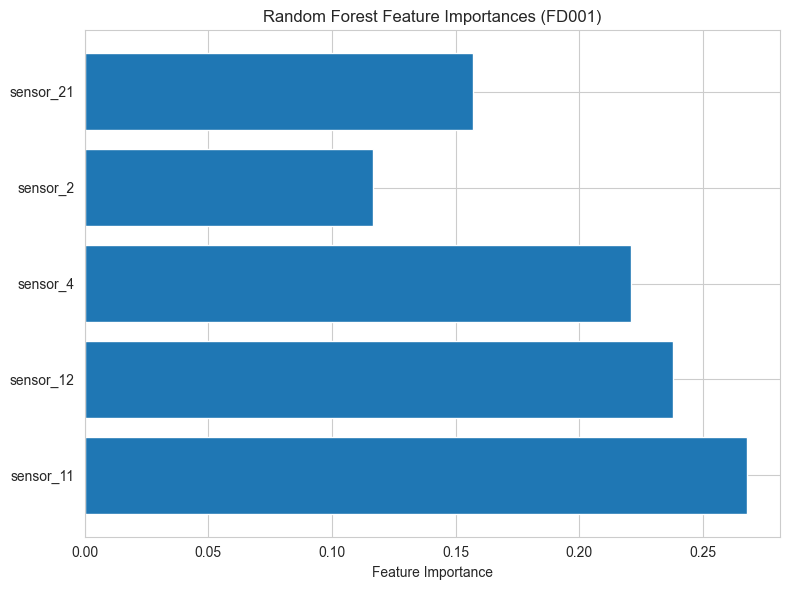


✅ Feature importance plot saved at: ..\figures\phase3\rf_fd001_feature_importances.png


In [13]:
# ============================================================
# Step 4: Random Forest Classifier Training + 5-Fold Cross Validation (FD001)
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib
import matplotlib.pyplot as plt

# 1. Initialize Random Forest Classifier
rf_model_fd001 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 2. Initialize 5-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 3. Perform 5-Fold Cross Validation on Training Set
cv_scores_rf = cross_val_score(
    rf_model_fd001,
    X_train_fd001,
    y_train_fd001,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

# 4. Display Cross-Validation Results
print("✅ Random Forest 5-Fold Cross Validation F1 Macro Scores:")
print(cv_scores_rf)
print("\n✅ Mean F1 Macro Score:", np.mean(cv_scores_rf))

# 5. Train Random Forest Model on Full Training Set
rf_model_fd001.fit(X_train_fd001, y_train_fd001)

# 6. Save Trained Model (correct path)
model_save_path = os.path.join('..', 'models', 'rf_fd001_model.pkl')
joblib.dump(rf_model_fd001, model_save_path)
print(f"\n✅ Trained Random Forest model saved at: {model_save_path}")

# ============================================================
# Step 4.5: Plot Feature Importances
# ============================================================

# 7. Plot Feature Importances
importances = rf_model_fd001.feature_importances_
feature_names = X_train_fd001.columns

plt.figure(figsize=(8, 6))
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances (FD001)')
plt.tight_layout()

# 8. Save Feature Importance Plot (correct path)
importance_plot_path = os.path.join('..', 'figures', 'phase3', 'rf_fd001_feature_importances.png')
plt.savefig(importance_plot_path)
plt.show()

print(f"\n✅ Feature importance plot saved at: {importance_plot_path}")


## Step 5: Random Forest Evaluation on Train and Test Sets (FD001)


✅ Random Forest Train Accuracy: 1.0000
✅ Random Forest Test Accuracy: 0.8214
✅ Train classification report saved at: ..\report\rf_fd001_train_classification_report.txt
✅ Test classification report saved at: ..\report\rf_fd001_test_classification_report.txt


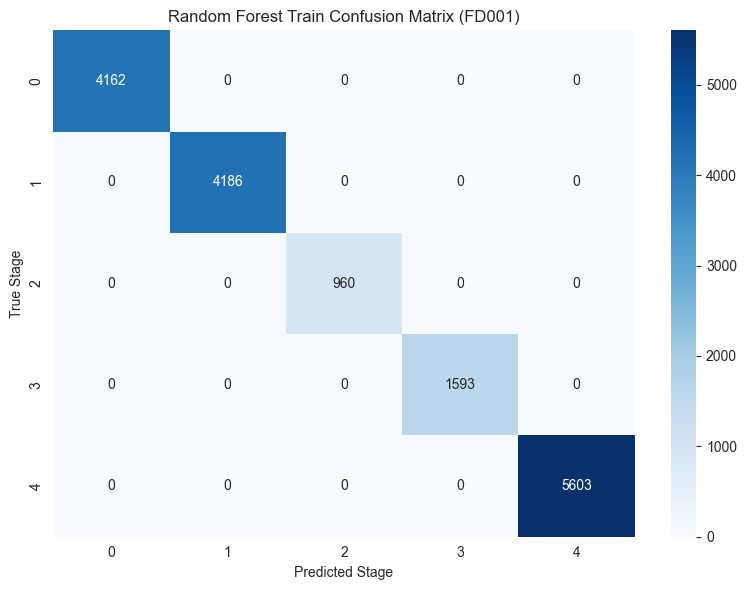

✅ Train Confusion Matrix plot saved at: ..\figures\phase3\rf_fd001_train_conf_matrix.png


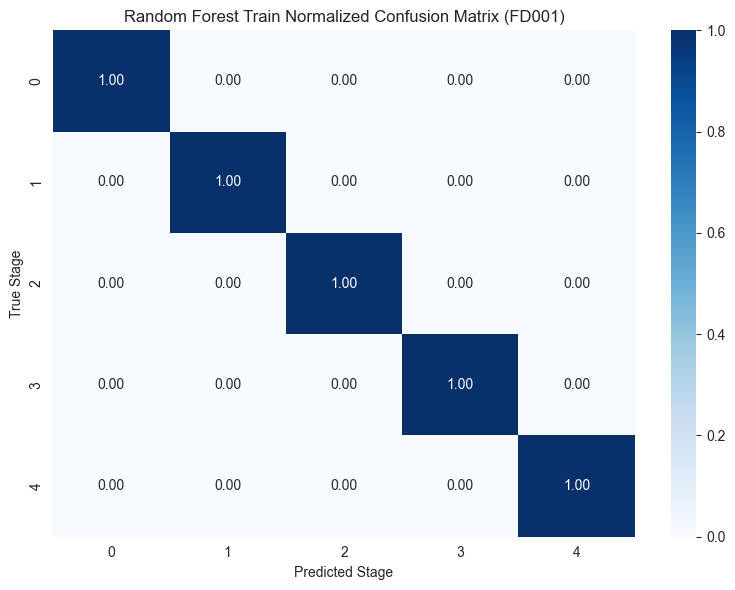

✅ Train Normalized Confusion Matrix plot saved at: ..\figures\phase3\rf_fd001_train_conf_matrix_normalized.png


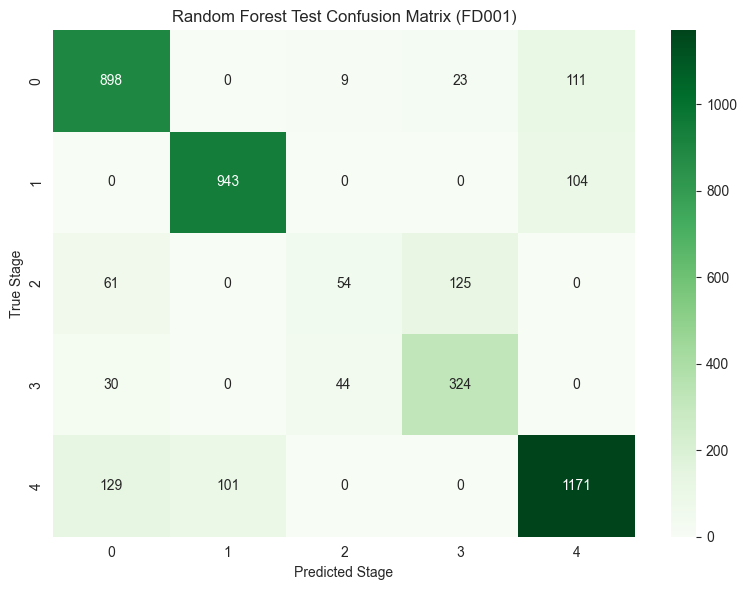

✅ Test Confusion Matrix plot saved at: ..\figures\phase3\rf_fd001_test_conf_matrix.png


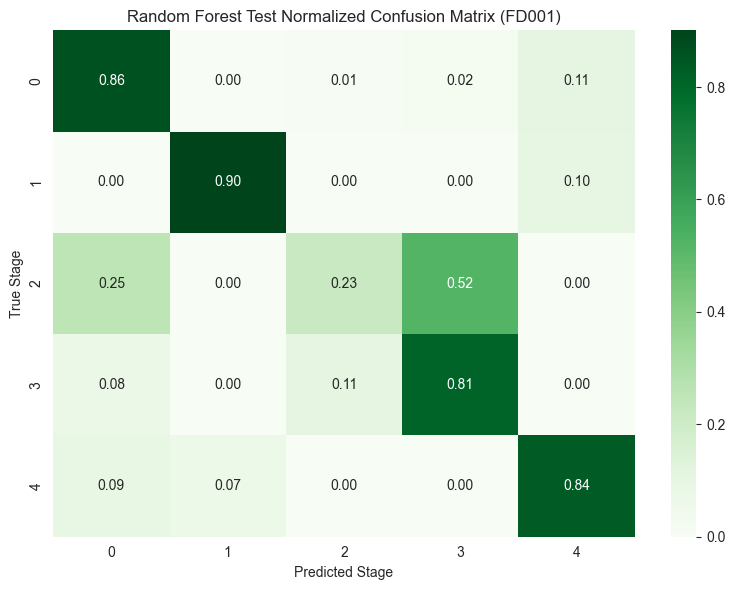

✅ Test Normalized Confusion Matrix plot saved at: ..\figures\phase3\rf_fd001_test_conf_matrix_normalized.png


In [14]:
# ============================================================
# Step 5: Random Forest Evaluation on Train and Test Sets (FD001)
# ============================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# 1. Predict on Train and Test Sets
y_train_pred_rf = rf_model_fd001.predict(X_train_fd001)
y_test_pred_rf = rf_model_fd001.predict(X_test_fd001)

# 2. Compute Metrics

# --- Training Metrics
train_accuracy_rf = accuracy_score(y_train_fd001, y_train_pred_rf)
print(f"✅ Random Forest Train Accuracy: {train_accuracy_rf:.4f}")

# --- Testing Metrics
test_accuracy_rf = accuracy_score(y_test_fd001, y_test_pred_rf)
print(f"✅ Random Forest Test Accuracy: {test_accuracy_rf:.4f}")

# 3. Save Classification Reports as .txt

# --- Train Classification Report
train_report_rf = classification_report(y_train_fd001, y_train_pred_rf)
train_report_path = os.path.join('..', 'report', 'rf_fd001_train_classification_report.txt')
with open(train_report_path, 'w') as f:
    f.write(train_report_rf)
print(f"✅ Train classification report saved at: {train_report_path}")

# --- Test Classification Report
test_report_rf = classification_report(y_test_fd001, y_test_pred_rf)
test_report_path = os.path.join('..', 'report', 'rf_fd001_test_classification_report.txt')
with open(test_report_path, 'w') as f:
    f.write(test_report_rf)
print(f"✅ Test classification report saved at: {test_report_path}")

# 4. Plot Confusion Matrices

# --- Train Confusion Matrix
conf_matrix_train = confusion_matrix(y_train_fd001, y_train_pred_rf)
conf_matrix_train_norm = confusion_matrix(y_train_fd001, y_train_pred_rf, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Train Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
train_conf_matrix_path = os.path.join('..', 'figures', 'phase3', 'rf_fd001_train_conf_matrix.png')
plt.savefig(train_conf_matrix_path)
plt.show()
print(f"✅ Train Confusion Matrix plot saved at: {train_conf_matrix_path}")

# --- Train Normalized Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train_norm, annot=True, fmt='.2f', cmap='Blues')
plt.title('Random Forest Train Normalized Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
train_conf_matrix_norm_path = os.path.join('..', 'figures', 'phase3', 'rf_fd001_train_conf_matrix_normalized.png')
plt.savefig(train_conf_matrix_norm_path)
plt.show()
print(f"✅ Train Normalized Confusion Matrix plot saved at: {train_conf_matrix_norm_path}")

# --- Test Confusion Matrix
conf_matrix_test = confusion_matrix(y_test_fd001, y_test_pred_rf)
conf_matrix_test_norm = confusion_matrix(y_test_fd001, y_test_pred_rf, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Test Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
test_conf_matrix_path = os.path.join('..', 'figures', 'phase3', 'rf_fd001_test_conf_matrix.png')
plt.savefig(test_conf_matrix_path)
plt.show()
print(f"✅ Test Confusion Matrix plot saved at: {test_conf_matrix_path}")

# --- Test Normalized Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_norm, annot=True, fmt='.2f', cmap='Greens')
plt.title('Random Forest Test Normalized Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
test_conf_matrix_norm_path = os.path.join('..', 'figures', 'phase3', 'rf_fd001_test_conf_matrix_normalized.png')
plt.savefig(test_conf_matrix_norm_path)
plt.show()
print(f"✅ Test Normalized Confusion Matrix plot saved at: {test_conf_matrix_norm_path}")


# Step 6: SVM Classifier Training + 5-Fold Cross Validation (FD001)

✅ SVM 5-Fold Cross Validation F1 Macro Scores:
[0.74448654 0.74721265 0.75801153 0.74339227 0.76068153]

✅ Mean F1 Macro Score: 0.750756904987778

✅ Trained SVM model saved at: ..\models\svm_fd001_model.pkl
✅ SVM Train Accuracy: 0.8288
✅ SVM Test Accuracy: 0.8238
✅ Train classification report saved at: ..\report\svm_fd001_train_classification_report.txt
✅ Test classification report saved at: ..\report\svm_fd001_test_classification_report.txt


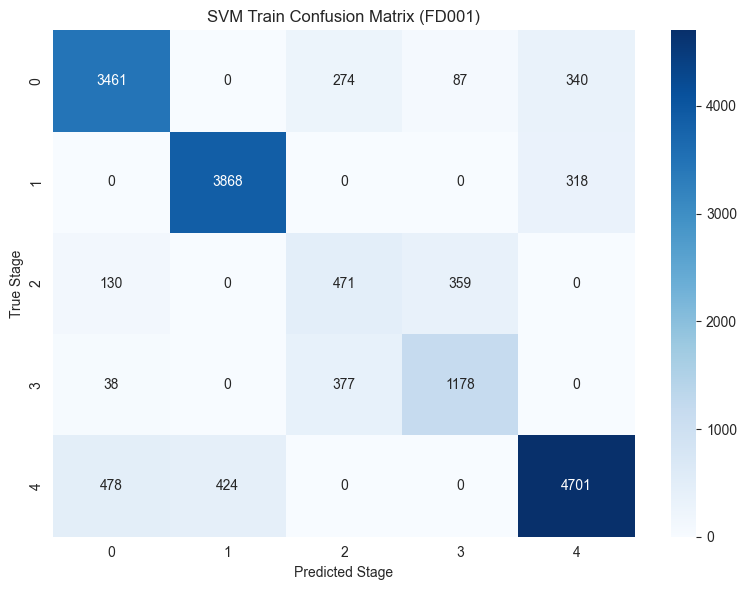

✅ Train Confusion Matrix plot saved at: ..\figures\phase3\svm_fd001_train_conf_matrix.png


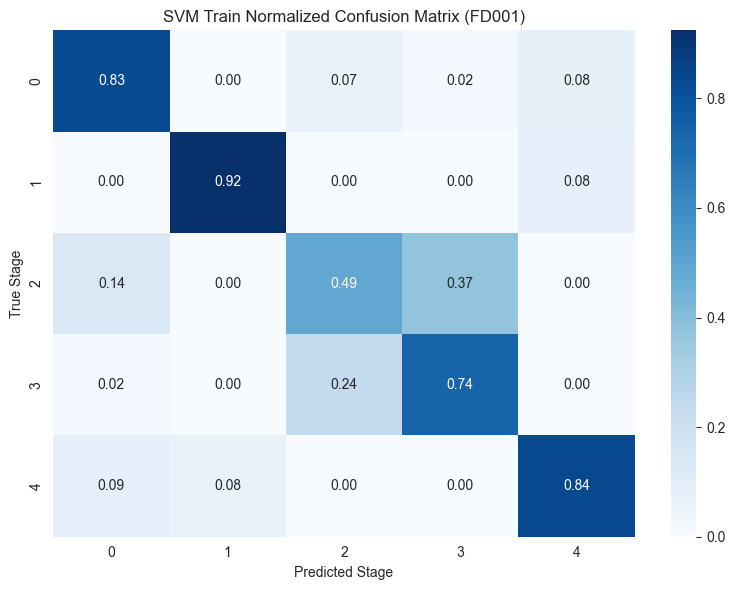

✅ Train Normalized Confusion Matrix plot saved at: ..\figures\phase3\svm_fd001_train_conf_matrix_normalized.png


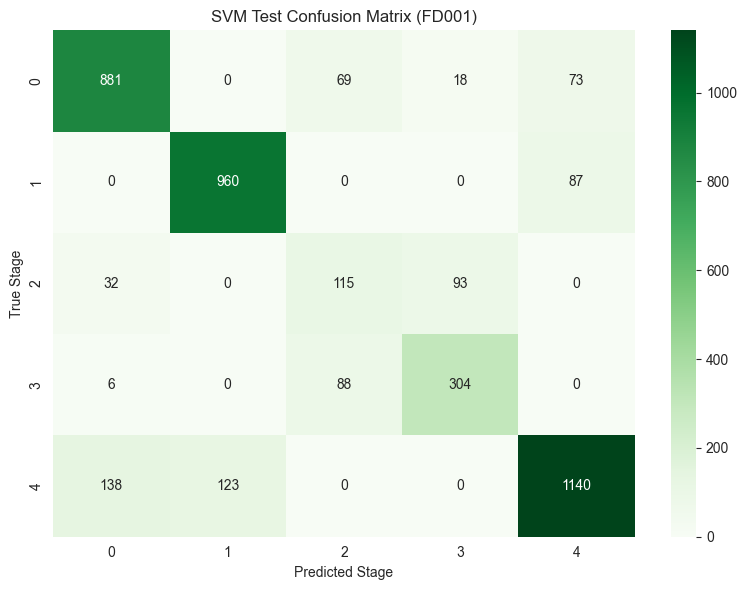

✅ Test Confusion Matrix plot saved at: ..\figures\phase3\svm_fd001_test_conf_matrix.png


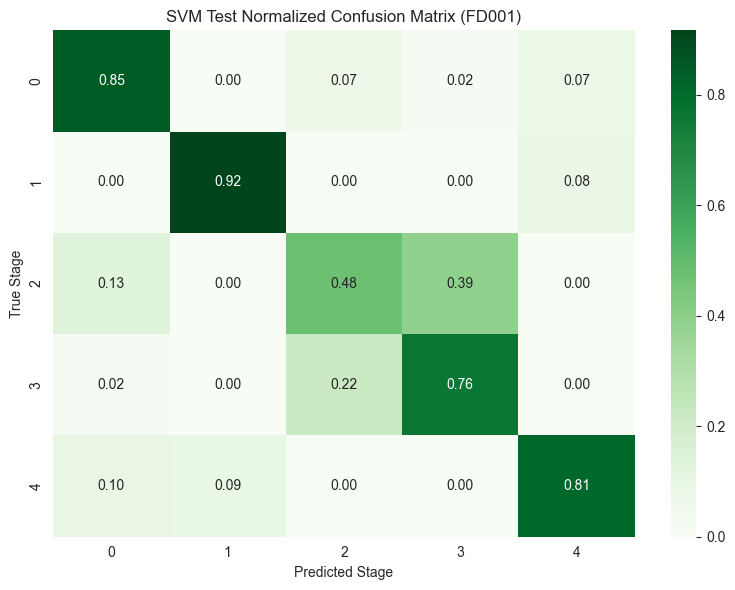

✅ Test Normalized Confusion Matrix plot saved at: ..\figures\phase3\svm_fd001_test_conf_matrix_normalized.png


In [15]:
# ============================================================
# Step 6: SVM Classifier Training + 5-Fold Cross Validation (FD001)
# ============================================================

from sklearn.svm import SVC

# 1. Initialize SVM Classifier
svm_model_fd001 = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)

# 2. Initialize 5-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 3. Perform 5-Fold Cross Validation on Training Set (SCALED features)
cv_scores_svm = cross_val_score(
    svm_model_fd001,
    X_train_scaled_fd001,
    y_train_fd001,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

# 4. Display Cross-Validation Results
print("✅ SVM 5-Fold Cross Validation F1 Macro Scores:")
print(cv_scores_svm)
print("\n✅ Mean F1 Macro Score:", np.mean(cv_scores_svm))

# 5. Train SVM Model on Full Training Set
svm_model_fd001.fit(X_train_scaled_fd001, y_train_fd001)

# 6. Save Trained SVM Model
svm_model_save_path = os.path.join('..', 'models', 'svm_fd001_model.pkl')
joblib.dump(svm_model_fd001, svm_model_save_path)
print(f"\n✅ Trained SVM model saved at: {svm_model_save_path}")

# ============================================================
# Step 6.5: Evaluate SVM on Train and Test Sets
# ============================================================

# 7. Predict on Train and Test Sets (scaled)
y_train_pred_svm = svm_model_fd001.predict(X_train_scaled_fd001)
y_test_pred_svm = svm_model_fd001.predict(X_test_scaled_fd001)

# 8. Compute Metrics

# --- Training Metrics
train_accuracy_svm = accuracy_score(y_train_fd001, y_train_pred_svm)
print(f"✅ SVM Train Accuracy: {train_accuracy_svm:.4f}")

# --- Testing Metrics
test_accuracy_svm = accuracy_score(y_test_fd001, y_test_pred_svm)
print(f"✅ SVM Test Accuracy: {test_accuracy_svm:.4f}")

# 9. Save Classification Reports as .txt

# --- Train Classification Report
train_report_svm = classification_report(y_train_fd001, y_train_pred_svm)
train_report_svm_path = os.path.join('..', 'report', 'svm_fd001_train_classification_report.txt')
with open(train_report_svm_path, 'w') as f:
    f.write(train_report_svm)
print(f"✅ Train classification report saved at: {train_report_svm_path}")

# --- Test Classification Report
test_report_svm = classification_report(y_test_fd001, y_test_pred_svm)
test_report_svm_path = os.path.join('..', 'report', 'svm_fd001_test_classification_report.txt')
with open(test_report_svm_path, 'w') as f:
    f.write(test_report_svm)
print(f"✅ Test classification report saved at: {test_report_svm_path}")

# ============================================================
# Step 6.6: Plot Confusion Matrices
# ============================================================

# --- Train Confusion Matrix
conf_matrix_train_svm = confusion_matrix(y_train_fd001, y_train_pred_svm)
conf_matrix_train_norm_svm = confusion_matrix(y_train_fd001, y_train_pred_svm, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train_svm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Train Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
train_conf_matrix_path_svm = os.path.join('..', 'figures', 'phase3', 'svm_fd001_train_conf_matrix.png')
plt.savefig(train_conf_matrix_path_svm)
plt.show()
print(f"✅ Train Confusion Matrix plot saved at: {train_conf_matrix_path_svm}")

# --- Train Normalized Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train_norm_svm, annot=True, fmt='.2f', cmap='Blues')
plt.title('SVM Train Normalized Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
train_conf_matrix_norm_path_svm = os.path.join('..', 'figures', 'phase3', 'svm_fd001_train_conf_matrix_normalized.png')
plt.savefig(train_conf_matrix_norm_path_svm)
plt.show()
print(f"✅ Train Normalized Confusion Matrix plot saved at: {train_conf_matrix_norm_path_svm}")

# --- Test Confusion Matrix
conf_matrix_test_svm = confusion_matrix(y_test_fd001, y_test_pred_svm)
conf_matrix_test_norm_svm = confusion_matrix(y_test_fd001, y_test_pred_svm, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_svm, annot=True, fmt='d', cmap='Greens')
plt.title('SVM Test Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
test_conf_matrix_path_svm = os.path.join('..', 'figures', 'phase3', 'svm_fd001_test_conf_matrix.png')
plt.savefig(test_conf_matrix_path_svm)
plt.show()
print(f"✅ Test Confusion Matrix plot saved at: {test_conf_matrix_path_svm}")

# --- Test Normalized Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_norm_svm, annot=True, fmt='.2f', cmap='Greens')
plt.title('SVM Test Normalized Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
test_conf_matrix_norm_path_svm = os.path.join('..', 'figures', 'phase3', 'svm_fd001_test_conf_matrix_normalized.png')
plt.savefig(test_conf_matrix_norm_path_svm)
plt.show()
print(f"✅ Test Normalized Confusion Matrix plot saved at: {test_conf_matrix_norm_path_svm}")


# Step 7: Logistic Regression Classifier Training + 5-Fold Cross Validation (FD001)

✅ Logistic Regression 5-Fold Cross Validation F1 Macro Scores:
[0.73902088 0.74877005 0.7580584  0.74242818 0.76109053]

✅ Mean F1 Macro Score: 0.749873608149598


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



✅ Trained Logistic Regression model saved at: ..\models\lr_fd001_model.pkl
✅ Logistic Regression Train Accuracy: 0.8210
✅ Logistic Regression Test Accuracy: 0.8190
✅ Train classification report saved at: ..\report\lr_fd001_train_classification_report.txt
✅ Test classification report saved at: ..\report\lr_fd001_test_classification_report.txt


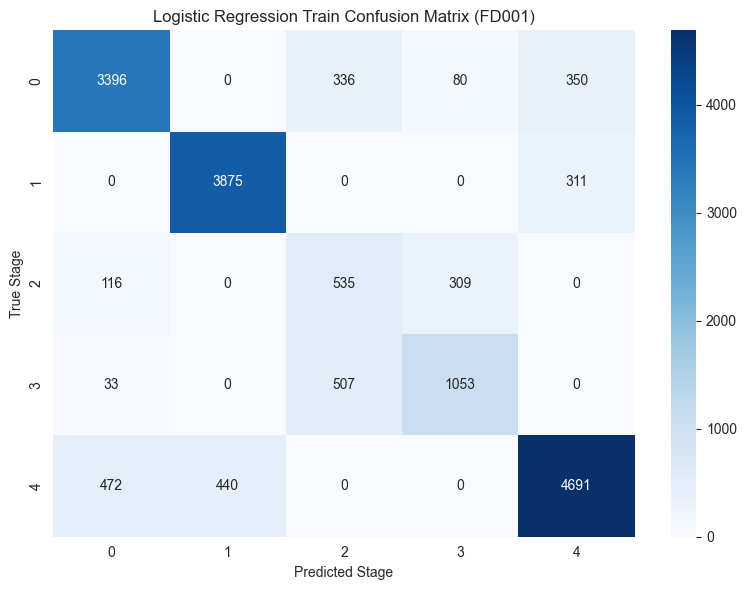

✅ Train Confusion Matrix plot saved at: ..\figures\phase3\lr_fd001_train_conf_matrix.png


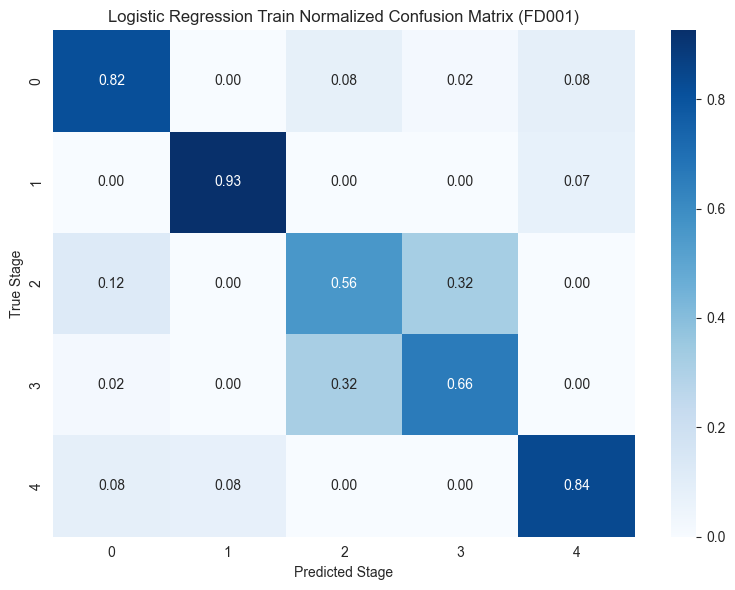

✅ Train Normalized Confusion Matrix plot saved at: ..\figures\phase3\lr_fd001_train_conf_matrix_normalized.png


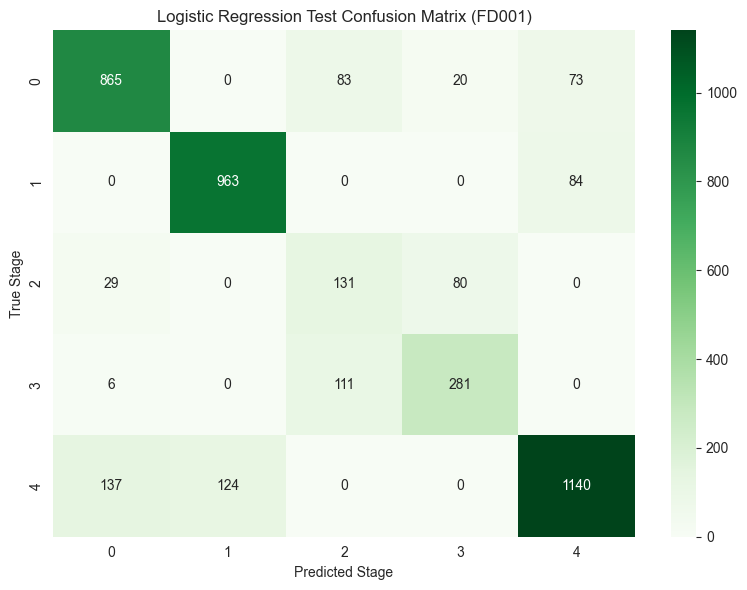

✅ Test Confusion Matrix plot saved at: ..\figures\phase3\lr_fd001_test_conf_matrix.png


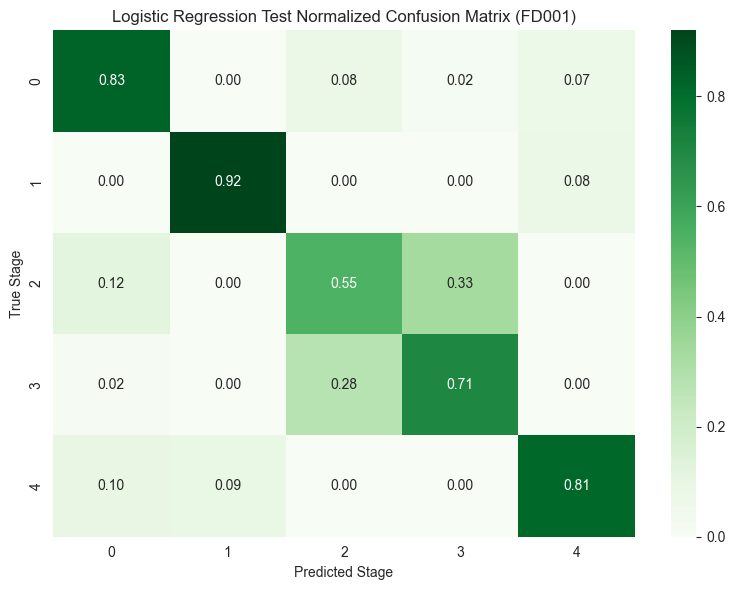

✅ Test Normalized Confusion Matrix plot saved at: ..\figures\phase3\lr_fd001_test_conf_matrix_normalized.png


In [16]:
# ============================================================
# Step 7: Logistic Regression Classifier Training + 5-Fold Cross Validation (FD001)
# ============================================================

from sklearn.linear_model import LogisticRegression

# 1. Initialize Logistic Regression Classifier
lr_model_fd001 = LogisticRegression(
    solver='lbfgs',
    multi_class='multinomial',
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# 2. Initialize 5-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 3. Perform 5-Fold Cross Validation on Training Set (SCALED features)
cv_scores_lr = cross_val_score(
    lr_model_fd001,
    X_train_scaled_fd001,
    y_train_fd001,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

# 4. Display Cross-Validation Results
print("✅ Logistic Regression 5-Fold Cross Validation F1 Macro Scores:")
print(cv_scores_lr)
print("\n✅ Mean F1 Macro Score:", np.mean(cv_scores_lr))

# 5. Train Logistic Regression Model on Full Training Set
lr_model_fd001.fit(X_train_scaled_fd001, y_train_fd001)

# 6. Save Trained Logistic Regression Model
lr_model_save_path = os.path.join('..', 'models', 'lr_fd001_model.pkl')
joblib.dump(lr_model_fd001, lr_model_save_path)
print(f"\n✅ Trained Logistic Regression model saved at: {lr_model_save_path}")

# ============================================================
# Step 7.5: Evaluate Logistic Regression on Train and Test Sets
# ============================================================

# 7. Predict on Train and Test Sets (scaled)
y_train_pred_lr = lr_model_fd001.predict(X_train_scaled_fd001)
y_test_pred_lr = lr_model_fd001.predict(X_test_scaled_fd001)

# 8. Compute Metrics

# --- Training Metrics
train_accuracy_lr = accuracy_score(y_train_fd001, y_train_pred_lr)
print(f"✅ Logistic Regression Train Accuracy: {train_accuracy_lr:.4f}")

# --- Testing Metrics
test_accuracy_lr = accuracy_score(y_test_fd001, y_test_pred_lr)
print(f"✅ Logistic Regression Test Accuracy: {test_accuracy_lr:.4f}")

# 9. Save Classification Reports as .txt

# --- Train Classification Report
train_report_lr = classification_report(y_train_fd001, y_train_pred_lr)
train_report_lr_path = os.path.join('..', 'report', 'lr_fd001_train_classification_report.txt')
with open(train_report_lr_path, 'w') as f:
    f.write(train_report_lr)
print(f"✅ Train classification report saved at: {train_report_lr_path}")

# --- Test Classification Report
test_report_lr = classification_report(y_test_fd001, y_test_pred_lr)
test_report_lr_path = os.path.join('..', 'report', 'lr_fd001_test_classification_report.txt')
with open(test_report_lr_path, 'w') as f:
    f.write(test_report_lr)
print(f"✅ Test classification report saved at: {test_report_lr_path}")

# ============================================================
# Step 7.6: Plot Confusion Matrices
# ============================================================

# --- Train Confusion Matrix
conf_matrix_train_lr = confusion_matrix(y_train_fd001, y_train_pred_lr)
conf_matrix_train_norm_lr = confusion_matrix(y_train_fd001, y_train_pred_lr, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Train Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
train_conf_matrix_path_lr = os.path.join('..', 'figures', 'phase3', 'lr_fd001_train_conf_matrix.png')
plt.savefig(train_conf_matrix_path_lr)
plt.show()
print(f"✅ Train Confusion Matrix plot saved at: {train_conf_matrix_path_lr}")

# --- Train Normalized Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train_norm_lr, annot=True, fmt='.2f', cmap='Blues')
plt.title('Logistic Regression Train Normalized Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
train_conf_matrix_norm_path_lr = os.path.join('..', 'figures', 'phase3', 'lr_fd001_train_conf_matrix_normalized.png')
plt.savefig(train_conf_matrix_norm_path_lr)
plt.show()
print(f"✅ Train Normalized Confusion Matrix plot saved at: {train_conf_matrix_norm_path_lr}")

# --- Test Confusion Matrix
conf_matrix_test_lr = confusion_matrix(y_test_fd001, y_test_pred_lr)
conf_matrix_test_norm_lr = confusion_matrix(y_test_fd001, y_test_pred_lr, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_lr, annot=True, fmt='d', cmap='Greens')
plt.title('Logistic Regression Test Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
test_conf_matrix_path_lr = os.path.join('..', 'figures', 'phase3', 'lr_fd001_test_conf_matrix.png')
plt.savefig(test_conf_matrix_path_lr)
plt.show()
print(f"✅ Test Confusion Matrix plot saved at: {test_conf_matrix_path_lr}")

# --- Test Normalized Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_norm_lr, annot=True, fmt='.2f', cmap='Greens')
plt.title('Logistic Regression Test Normalized Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
test_conf_matrix_norm_path_lr = os.path.join('..', 'figures', 'phase3', 'lr_fd001_test_conf_matrix_normalized.png')
plt.savefig(test_conf_matrix_norm_path_lr)
plt.show()
print(f"✅ Test Normalized Confusion Matrix plot saved at: {test_conf_matrix_norm_path_lr}")


# Step 8: XGBoost Classifier Training + 5-Fold Cross Validation (FD001)


In [18]:
# ============================================================
# Step 8.0: Encode Labels for XGBoost
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Initialize Label Encoder
label_encoder = LabelEncoder()

# Fit only on training labels
y_train_fd001_encoded = label_encoder.fit_transform(y_train_fd001)
y_test_fd001_encoded = label_encoder.transform(y_test_fd001)

# Now y_train_fd001_encoded and y_test_fd001_encoded are numeric labels (0,1,2,3,4)
print("✅ Label Encoding Done. Classes:", label_encoder.classes_)


✅ Label Encoding Done. Classes: ['Stage 0' 'Stage 1' 'Stage 2' 'Stage 3' 'Stage 4']


✅ XGBoost 5-Fold Cross Validation F1 Macro Scores:
[0.73432061 0.72966764 0.75432304 0.7477103  0.74798352]

✅ Mean F1 Macro Score: 0.7428010222777833


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:29:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Trained XGBoost model saved at: ..\models\xgb_fd001_model.pkl
✅ XGBoost Train Accuracy: 0.8897
✅ XGBoost Test Accuracy: 0.8294
✅ Train classification report saved at: ..\report\xgb_fd001_train_classification_report.txt
✅ Test classification report saved at: ..\report\xgb_fd001_test_classification_report.txt


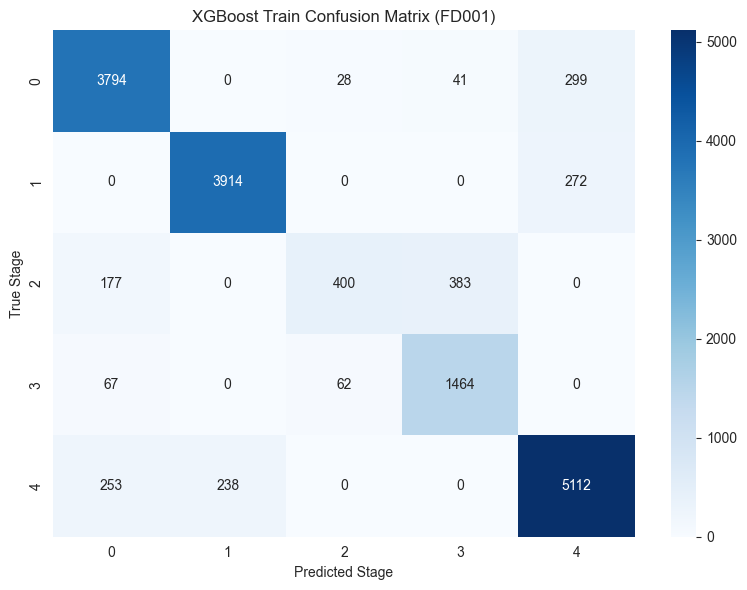

✅ Train Confusion Matrix plot saved at: ..\figures\phase3\xgb_fd001_train_conf_matrix.png


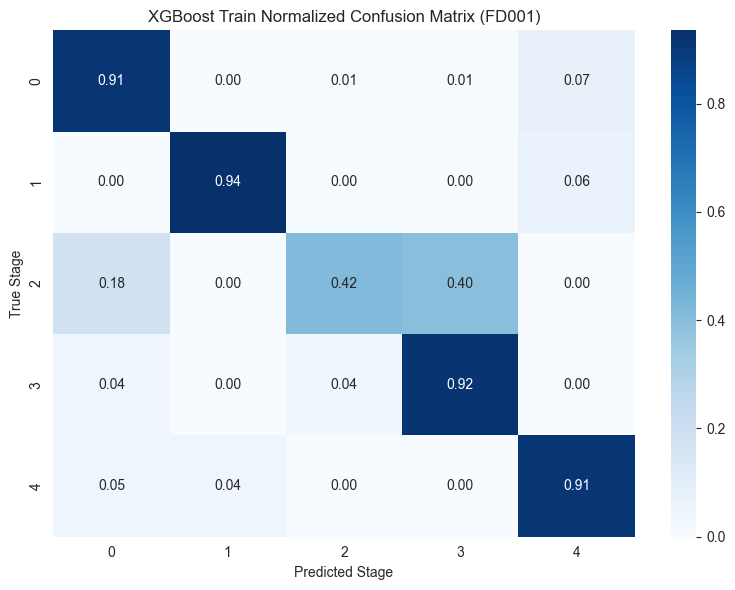

✅ Train Normalized Confusion Matrix plot saved at: ..\figures\phase3\xgb_fd001_train_conf_matrix_normalized.png


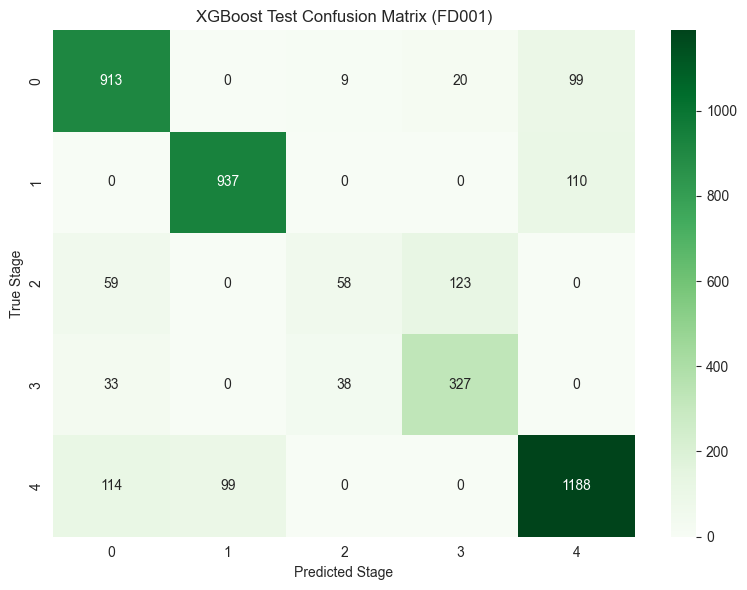

✅ Test Confusion Matrix plot saved at: ..\figures\phase3\xgb_fd001_test_conf_matrix.png


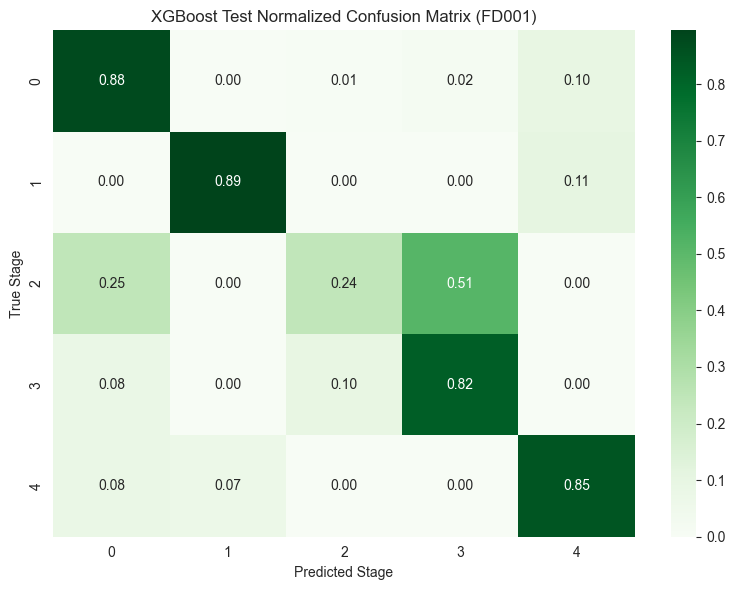

✅ Test Normalized Confusion Matrix plot saved at: ..\figures\phase3\xgb_fd001_test_conf_matrix_normalized.png


In [19]:
# ============================================================
# Step 8: XGBoost Classifier Training + 5-Fold Cross Validation (FD001)
# ============================================================

from xgboost import XGBClassifier

# 1. Initialize XGBoost Classifier
xgb_model_fd001 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=5,
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# 2. Initialize 5-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 3. Perform 5-Fold Cross Validation on Training Set (UNSCALED features and ENCODED y)
cv_scores_xgb = cross_val_score(
    xgb_model_fd001,
    X_train_fd001,
    y_train_fd001_encoded,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

# 4. Display Cross-Validation Results
print("✅ XGBoost 5-Fold Cross Validation F1 Macro Scores:")
print(cv_scores_xgb)
print("\n✅ Mean F1 Macro Score:", np.mean(cv_scores_xgb))

# 5. Train XGBoost Model on Full Training Set
xgb_model_fd001.fit(X_train_fd001, y_train_fd001_encoded)

# 6. Save Trained XGBoost Model
xgb_model_save_path = os.path.join('..', 'models', 'xgb_fd001_model.pkl')
joblib.dump(xgb_model_fd001, xgb_model_save_path)
print(f"\n✅ Trained XGBoost model saved at: {xgb_model_save_path}")

# ============================================================
# Step 8.5: Evaluate XGBoost on Train and Test Sets
# ============================================================

# 7. Predict on Train and Test Sets (unscaled)
y_train_pred_xgb = xgb_model_fd001.predict(X_train_fd001)
y_test_pred_xgb = xgb_model_fd001.predict(X_test_fd001)

# 🚨 Decode predictions back to original labels
y_train_pred_xgb_decoded = label_encoder.inverse_transform(y_train_pred_xgb)
y_test_pred_xgb_decoded = label_encoder.inverse_transform(y_test_pred_xgb)

# 🚨 Also decode encoded true labels for accurate metrics
y_train_true_decoded = label_encoder.inverse_transform(y_train_fd001_encoded)
y_test_true_decoded = label_encoder.inverse_transform(y_test_fd001_encoded)

# 8. Compute Metrics

# --- Training Metrics
train_accuracy_xgb = accuracy_score(y_train_true_decoded, y_train_pred_xgb_decoded)
print(f"✅ XGBoost Train Accuracy: {train_accuracy_xgb:.4f}")

# --- Testing Metrics
test_accuracy_xgb = accuracy_score(y_test_true_decoded, y_test_pred_xgb_decoded)
print(f"✅ XGBoost Test Accuracy: {test_accuracy_xgb:.4f}")

# 9. Save Classification Reports as .txt

# --- Train Classification Report
train_report_xgb = classification_report(y_train_true_decoded, y_train_pred_xgb_decoded)
train_report_xgb_path = os.path.join('..', 'report', 'xgb_fd001_train_classification_report.txt')
with open(train_report_xgb_path, 'w') as f:
    f.write(train_report_xgb)
print(f"✅ Train classification report saved at: {train_report_xgb_path}")

# --- Test Classification Report
test_report_xgb = classification_report(y_test_true_decoded, y_test_pred_xgb_decoded)
test_report_xgb_path = os.path.join('..', 'report', 'xgb_fd001_test_classification_report.txt')
with open(test_report_xgb_path, 'w') as f:
    f.write(test_report_xgb)
print(f"✅ Test classification report saved at: {test_report_xgb_path}")

# ============================================================
# Step 8.6: Plot Confusion Matrices
# ============================================================

# --- Train Confusion Matrix
conf_matrix_train_xgb = confusion_matrix(y_train_true_decoded, y_train_pred_xgb_decoded)
conf_matrix_train_norm_xgb = confusion_matrix(y_train_true_decoded, y_train_pred_xgb_decoded, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Train Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
train_conf_matrix_path_xgb = os.path.join('..', 'figures', 'phase3', 'xgb_fd001_train_conf_matrix.png')
plt.savefig(train_conf_matrix_path_xgb)
plt.show()
print(f"✅ Train Confusion Matrix plot saved at: {train_conf_matrix_path_xgb}")

# --- Train Normalized Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train_norm_xgb, annot=True, fmt='.2f', cmap='Blues')
plt.title('XGBoost Train Normalized Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
train_conf_matrix_norm_path_xgb = os.path.join('..', 'figures', 'phase3', 'xgb_fd001_train_conf_matrix_normalized.png')
plt.savefig(train_conf_matrix_norm_path_xgb)
plt.show()
print(f"✅ Train Normalized Confusion Matrix plot saved at: {train_conf_matrix_norm_path_xgb}")

# --- Test Confusion Matrix
conf_matrix_test_xgb = confusion_matrix(y_test_true_decoded, y_test_pred_xgb_decoded)
conf_matrix_test_norm_xgb = confusion_matrix(y_test_true_decoded, y_test_pred_xgb_decoded, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_xgb, annot=True, fmt='d', cmap='Greens')
plt.title('XGBoost Test Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
test_conf_matrix_path_xgb = os.path.join('..', 'figures', 'phase3', 'xgb_fd001_test_conf_matrix.png')
plt.savefig(test_conf_matrix_path_xgb)
plt.show()
print(f"✅ Test Confusion Matrix plot saved at: {test_conf_matrix_path_xgb}")

# --- Test Normalized Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_norm_xgb, annot=True, fmt='.2f', cmap='Greens')
plt.title('XGBoost Test Normalized Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
test_conf_matrix_norm_path_xgb = os.path.join('..', 'figures', 'phase3', 'xgb_fd001_test_conf_matrix_normalized.png')
plt.savefig(test_conf_matrix_norm_path_xgb)
plt.show()
print(f"✅ Test Normalized Confusion Matrix plot saved at: {test_conf_matrix_norm_path_xgb}")


# ============================================================
# Phase 3 (FD001) - Step 4A: Random Forest Hyperparameter Tuning
# ============================================================


✅ Corrected FD001 dataset loaded successfully.
✅ Feature and target variables selected.
✅ Train/Test split done: Train shape (16504, 5), Test shape (4127, 5)
✅ Starting Grid Search for FD001 Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Grid Search Completed for FD001.
Best Hyperparameters Found: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best F1 Macro Score: 0.7472023745921652
✅ Best Random Forest model retrained on full training data.
✅ Best Random Forest model saved at: ..\models\rf_fd001_best_model.pkl
✅ Tuned Random Forest Train Accuracy: 0.9018
✅ Tuned Random Forest Test Accuracy: 0.8197
✅ Train and Test classification reports (tuned) saved.


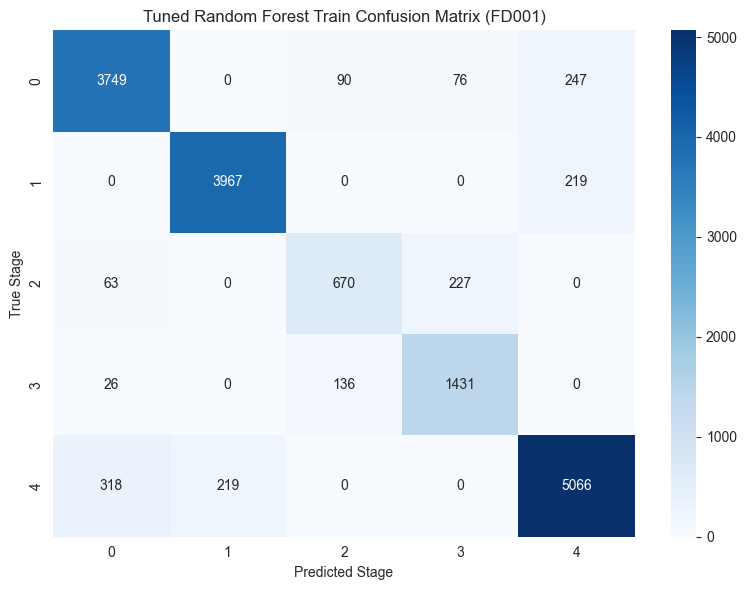

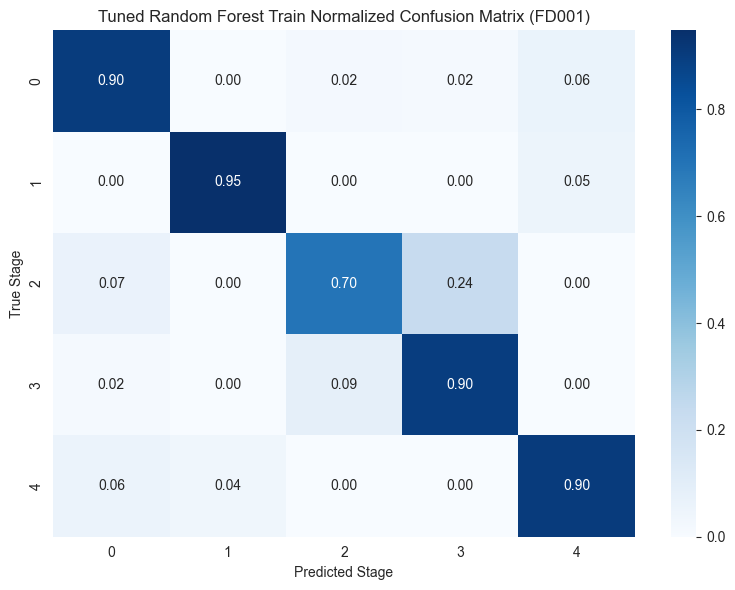

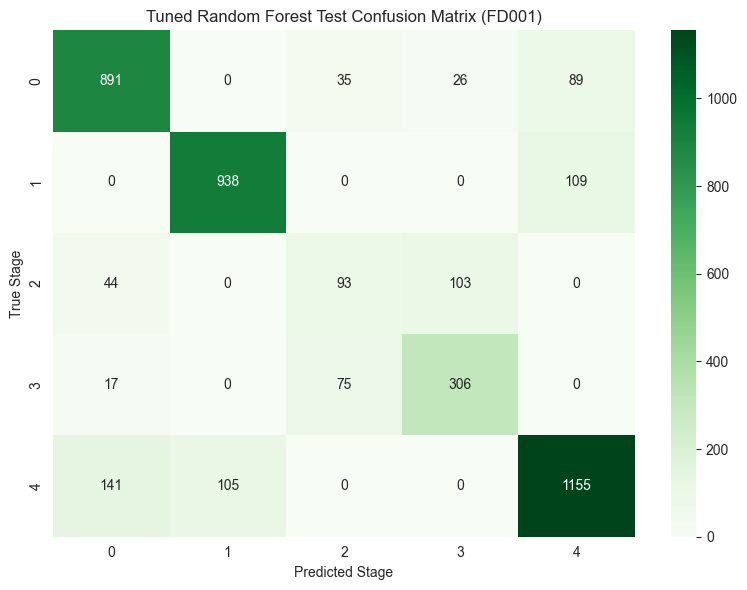

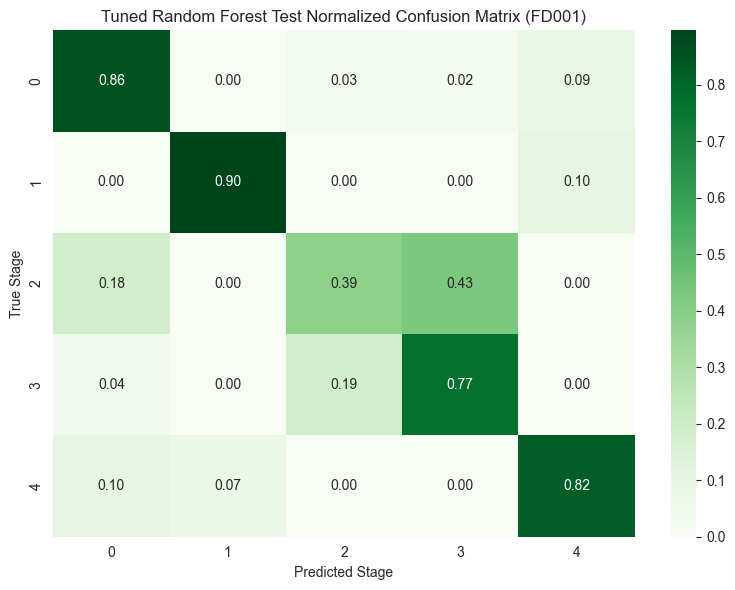

✅ Tuned Random Forest Confusion matrices saved and displayed.


In [21]:
# ============================================================
# Phase 3 (FD001) - Step 4A: Random Forest Hyperparameter Tuning
# ============================================================

# 1. Imports
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

# 2. Load FD001 Dataset
import pandas as pd

fd001_file_path = os.path.join('..', 'data', 'corrected_clustered_train_FD001.csv')
df_fd001 = pd.read_csv(fd001_file_path)

print("✅ Corrected FD001 dataset loaded successfully.")

# 3. Feature and Target Selection
top5_sensors_fd001 = ['sensor_11', 'sensor_12', 'sensor_4', 'sensor_2', 'sensor_21']
X_fd001 = df_fd001[top5_sensors_fd001]
y_fd001 = df_fd001['kmeans_stage']

print("✅ Feature and target variables selected.")

# 4. Train-Test Split (Stratified)
X_train_fd001, X_test_fd001, y_train_fd001, y_test_fd001 = train_test_split(
    X_fd001, y_fd001, 
    test_size=0.2, 
    stratify=y_fd001, 
    random_state=42
)

print(f"✅ Train/Test split done: Train shape {X_train_fd001.shape}, Test shape {X_test_fd001.shape}")

# 5. Setup Parameter Grid for Tuning
param_grid_rf_fd001 = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 6. Setup GridSearchCV
rf_clf_fd001 = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search_rf_fd001 = GridSearchCV(
    estimator=rf_clf_fd001,
    param_grid=param_grid_rf_fd001,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=2
)

print("✅ Starting Grid Search for FD001 Random Forest...")

# 7. Perform Hyperparameter Tuning
grid_search_rf_fd001.fit(X_train_fd001, y_train_fd001)

print("\n✅ Grid Search Completed for FD001.")
print("Best Hyperparameters Found:", grid_search_rf_fd001.best_params_)
print("Best F1 Macro Score:", grid_search_rf_fd001.best_score_)

# 8. Retrain Best Random Forest Model on Full Training Set
best_rf_fd001 = grid_search_rf_fd001.best_estimator_
best_rf_fd001.fit(X_train_fd001, y_train_fd001)

print("✅ Best Random Forest model retrained on full training data.")

# 9. Save Trained Best Model
best_rf_save_path_fd001 = os.path.join('..', 'models', 'rf_fd001_best_model.pkl')
joblib.dump(best_rf_fd001, best_rf_save_path_fd001)
print(f"✅ Best Random Forest model saved at: {best_rf_save_path_fd001}")

# ============================================================
# Phase 3 (FD001) - Step 4B: Random Forest Evaluation (Tuned)
# ============================================================

# 10. Predict and Evaluate
y_train_pred_rf_fd001 = best_rf_fd001.predict(X_train_fd001)
y_test_pred_rf_fd001 = best_rf_fd001.predict(X_test_fd001)

# Train Metrics
train_accuracy_rf_fd001 = accuracy_score(y_train_fd001, y_train_pred_rf_fd001)
print(f"✅ Tuned Random Forest Train Accuracy: {train_accuracy_rf_fd001:.4f}")

# Test Metrics
test_accuracy_rf_fd001 = accuracy_score(y_test_fd001, y_test_pred_rf_fd001)
print(f"✅ Tuned Random Forest Test Accuracy: {test_accuracy_rf_fd001:.4f}")

# Save Train Classification Report
train_report_rf_fd001 = classification_report(y_train_fd001, y_train_pred_rf_fd001)
train_report_rf_path_fd001 = os.path.join('..', 'report', 'rf_fd001_train_classification_report_tuned.txt')
with open(train_report_rf_path_fd001, 'w') as f:
    f.write(train_report_rf_fd001)

# Save Test Classification Report
test_report_rf_fd001 = classification_report(y_test_fd001, y_test_pred_rf_fd001)
test_report_rf_path_fd001 = os.path.join('..', 'report', 'rf_fd001_test_classification_report_tuned.txt')
with open(test_report_rf_path_fd001, 'w') as f:
    f.write(test_report_rf_fd001)

print(f"✅ Train and Test classification reports (tuned) saved.")

# 11. Confusion Matrices

# --- Train Confusion Matrix
conf_matrix_train_rf_fd001 = confusion_matrix(y_train_fd001, y_train_pred_rf_fd001)
conf_matrix_train_norm_rf_fd001 = confusion_matrix(y_train_fd001, y_train_pred_rf_fd001, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train_rf_fd001, annot=True, fmt='d', cmap='Blues')
plt.title('Tuned Random Forest Train Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
train_conf_matrix_path_rf_fd001 = os.path.join('..', 'figures', 'phase3', 'rf_fd001_train_conf_matrix_tuned.png')
plt.savefig(train_conf_matrix_path_rf_fd001)
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train_norm_rf_fd001, annot=True, fmt='.2f', cmap='Blues')
plt.title('Tuned Random Forest Train Normalized Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
train_conf_matrix_norm_path_rf_fd001 = os.path.join('..', 'figures', 'phase3', 'rf_fd001_train_conf_matrix_normalized_tuned.png')
plt.savefig(train_conf_matrix_norm_path_rf_fd001)
plt.show()

# --- Test Confusion Matrix
conf_matrix_test_rf_fd001 = confusion_matrix(y_test_fd001, y_test_pred_rf_fd001)
conf_matrix_test_norm_rf_fd001 = confusion_matrix(y_test_fd001, y_test_pred_rf_fd001, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_rf_fd001, annot=True, fmt='d', cmap='Greens')
plt.title('Tuned Random Forest Test Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
test_conf_matrix_path_rf_fd001 = os.path.join('..', 'figures', 'phase3', 'rf_fd001_test_conf_matrix_tuned.png')
plt.savefig(test_conf_matrix_path_rf_fd001)
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_norm_rf_fd001, annot=True, fmt='.2f', cmap='Greens')
plt.title('Tuned Random Forest Test Normalized Confusion Matrix (FD001)')
plt.xlabel('Predicted Stage')
plt.ylabel('True Stage')
plt.tight_layout()
test_conf_matrix_norm_path_rf_fd001 = os.path.join('..', 'figures', 'phase3', 'rf_fd001_test_conf_matrix_normalized_tuned.png')
plt.savefig(test_conf_matrix_norm_path_rf_fd001)
plt.show()

print("✅ Tuned Random Forest Confusion matrices saved and displayed.")


# Final Step: Model Comparison Table + Bar Plot

✅ Model Comparison Table:

                 Model  Train Accuracy  Test Accuracy  \
0        Random Forest          1.0000         0.8214   
1                  SVM          0.8288         0.8238   
2  Logistic Regression          0.8210         0.8190   
3              XGBoost          0.8897         0.8294   

   Mean F1 Macro Score (CV)  
0                    0.7326  
1                    0.7508  
2                    0.7499  
3                    0.7428  

✅ Model Comparison Table saved at: ..\report\phase3_model_comparison.csv


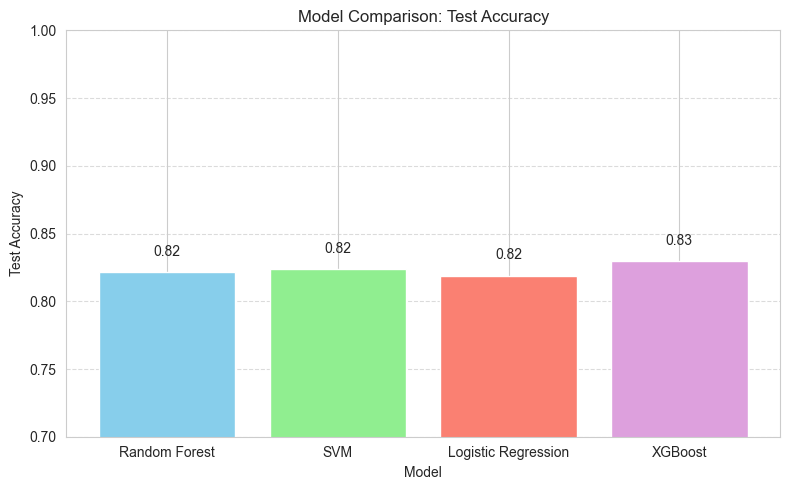


✅ Model Comparison Bar Plot saved at: ..\figures\phase3\model_comparison_test_accuracy.png


In [20]:
# ============================================================
# Final Step: Model Comparison Table + Bar Plot
# ============================================================

import pandas as pd

# 1. Prepare Results Manually

model_comparison = {
    'Model': ['Random Forest', 'SVM', 'Logistic Regression', 'XGBoost'],
    'Train Accuracy': [1.0000, 0.8288, 0.8210, 0.8897],
    'Test Accuracy': [0.8214, 0.8238, 0.8190, 0.8294],
    'Mean F1 Macro Score (CV)': [0.7326, 0.7508, 0.7499, 0.7428]
}

# 2. Create DataFrame

comparison_df = pd.DataFrame(model_comparison)
print("✅ Model Comparison Table:\n")
print(comparison_df)

# 3. Save Comparison Table as CSV

comparison_table_path = os.path.join('..', 'report', 'phase3_model_comparison.csv')
comparison_df.to_csv(comparison_table_path, index=False)
print(f"\n✅ Model Comparison Table saved at: {comparison_table_path}")

# ============================================================
# Final Step: Plot Bar Chart of Test Accuracies
# ============================================================

import matplotlib.pyplot as plt

# 4. Plot Test Accuracies

plt.figure(figsize=(8, 5))
bars = plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'], color=['skyblue', 'lightgreen', 'salmon', 'plum'])
plt.ylim(0.7, 1.0)
plt.title('Model Comparison: Test Accuracy')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

# Save Bar Plot

comparison_plot_path = os.path.join('..', 'figures', 'phase3', 'model_comparison_test_accuracy.png')
plt.tight_layout()
plt.savefig(comparison_plot_path)
plt.show()

print(f"\n✅ Model Comparison Bar Plot saved at: {comparison_plot_path}")
